<a href="https://colab.research.google.com/github/FinancialWisdomAI/FinancialWisdomSimulator/blob/main/Copy_of_financial_wisdom_simulator_basic_single_cell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Asset database loaded.

                         Asset  MeanReturn  StdDev
0           S&P 500 Index Fund      0.1185   0.194
1   60/40 Stock-Bond Portfolio      0.0800   0.120
2       Conservative Portfolio      0.0500   0.060
3                 US Large Cap      0.1185   0.194
4                 US Small Cap      0.1200   0.250
5         International Stocks      0.0850   0.170
6                        Bonds      0.0500   0.070
7                         Cash      0.0250   0.010
8                        REITs      0.1000   0.200
9                Growth Stocks      0.1300   0.230
10                Value Stocks      0.1100   0.180
11              Treasury Bonds      0.0400   0.050
12                        Gold      0.0600   0.150
 Financial Wisdom Monte Carlo Simulator


Portfolio Construction Method
1 - Predefined Portfolio
2 - Build Custom Portfolio

Available Assets
No.  Asset                                  Mean Return           Risk
------------------------------------------------

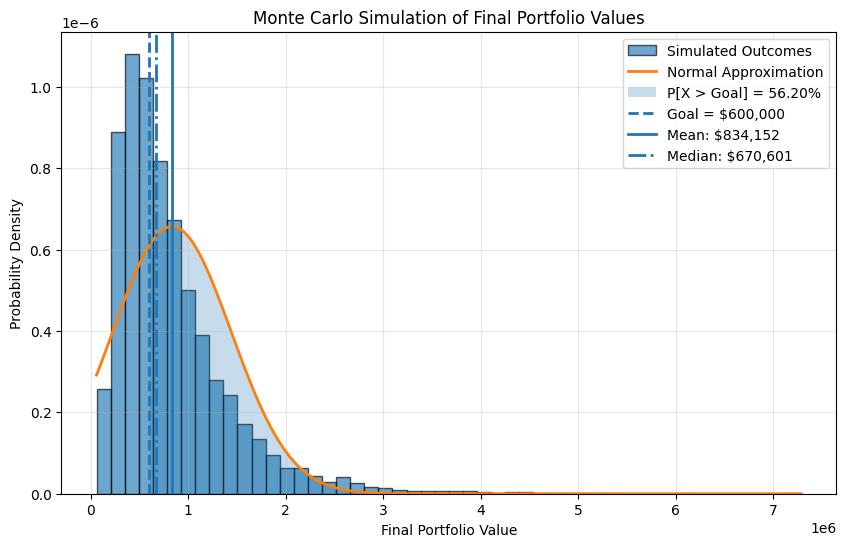

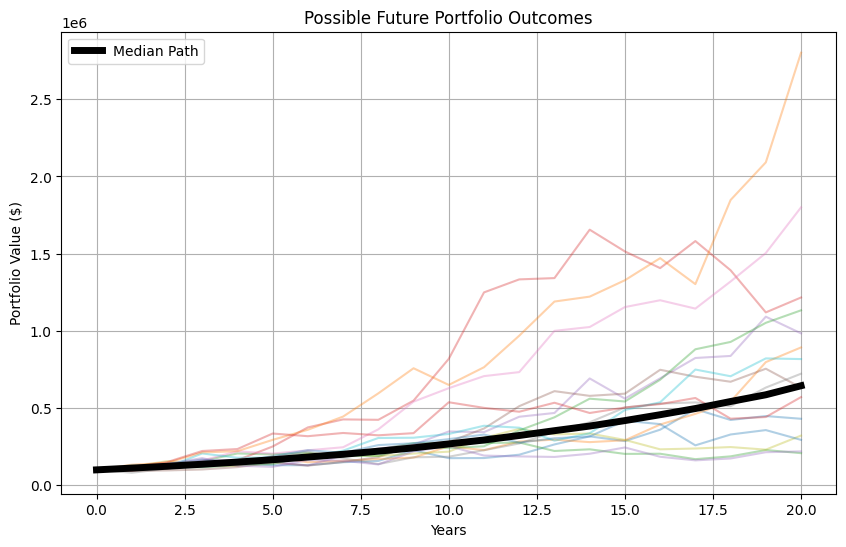


 Financial Wisdom Next Step
1 - Modify current plan and run again
2 - Start a completely new simulation
3 - Exit
Choose an option:


KeyboardInterrupt: Interrupted by user

In [ ]:
# ============================================================
# FINANCIAL WISDOM MONTE CARLO SIMULATOR
# Basic single-cell notebook version for Colab debugging
# ============================================================


# --------------------------- config.py ---------------------------
"""Configuration values for the Financial Wisdom Simulator."""

DEFAULT_NUM_SIMULATIONS = 10_000
RANDOM_SEED = None
MIN_ANNUAL_RETURN = -0.99

# --------------------------- user_inputs.py ---------------------------
"""User input and validation helpers."""
import sys

def _handle_control_command(response: str) -> None:
    command = response.strip().lower()

    if command in ["q", "quit", "exit"]:
        print("\nExiting Financial Wisdom Simulator.")
        sys.exit()

def get_money(prompt: str) -> float:
    while True:
        response = input(prompt).strip()
        _handle_control_command(response)

        try:
            return float(response.replace('$', '').replace(',', ''))
        except ValueError:
            print("Please enter a valid dollar amount. Type 'q' to quit.")


def get_integer(prompt: str) -> int:
    while True:
        response = input(prompt).strip()
        _handle_control_command(response)

        try:
            return int(response.replace('$', '').replace(',', ''))
        except ValueError:
            print("Please enter a whole number. Type 'q' to quit.")


def get_float(prompt: str) -> float:
    while True:
        response = input(prompt).strip()
        _handle_control_command(response)

        if response == "":
            return 0.0

        try:
            return float(response)
        except ValueError:
            print("Please enter a valid number. Type 'q' to quit.")


def get_yes_no(prompt: str) -> str:
    while True:
        response = input(prompt).strip().lower()
        _handle_control_command(response)

        if response in ["yes", "y"]:
            return "Yes"
        if response in ["no", "n"]:
            return "No"

        print("Please answer Yes or No. Type 'q' to quit.")


def get_user_inputs(asset_db) -> tuple[dict, dict]:
    print("======================================")
    print(" Financial Wisdom Monte Carlo Simulator")
    print("======================================\n")

    plan = {
        "goal_name": input("What is your financial goal? "),
        "goal_amount": get_money("What is your goal amount ($)? "),
        "years": get_integer("How many years until you need the money? "),
        "initial_balance": get_money("Initial investment amount ($): "),
        "monthly_contribution": get_money("Monthly contribution ($): "),
    }

    portfolio = choose_portfolio(asset_db)

    print("\n======================================")
    print(" Portfolio Statistics")
    print("======================================")
    print(f"Portfolio: {portfolio['portfolio_name']}")
    print(f"Expected Return: {portfolio['mean_return']:.2%}")
    print(f"Estimated Risk : {portfolio['std_return']:.2%}")

    print("\nRisk Tolerance")
    print("1 - Low")
    print("2 - Moderate")
    print("3 - High")
    plan["risk_tolerance"] = get_integer("Choose risk tolerance (1-3): ")

    plan["emergency_fund"] = get_yes_no(
        "\nDo you currently maintain an emergency fund? (yes/no): "
    )

    plan["high_interest_debt"] = get_yes_no(
        "Do you currently have high-interest debt? (yes/no): "
    )

    plan["num_simulations"] = get_integer(
        f"\nNumber of Monte Carlo simulations (e.g., {DEFAULT_NUM_SIMULATIONS}): "
    )

    inflation_input = input("Expected annual inflation rate (%) [default = 3]: ").strip()

    if inflation_input == "":
        plan["inflation_rate"] = 0.03
    else:
        plan["inflation_rate"] = float(inflation_input) / 100.0

    return plan, portfolio

# -------------------------------- portfolio.py --------------------------------
"""Asset database and portfolio construction."""
import pandas as pd

ASSET_DATA = [
    {"Asset": "S&P 500 Index Fund", "MeanReturn": 0.1185, "StdDev": 0.194},
    {"Asset": "60/40 Stock-Bond Portfolio", "MeanReturn": 0.0800, "StdDev": 0.120},
    {"Asset": "Conservative Portfolio", "MeanReturn": 0.0500, "StdDev": 0.060},
    {"Asset": "US Large Cap", "MeanReturn": 0.1185, "StdDev": 0.194},
    {"Asset": "US Small Cap", "MeanReturn": 0.1200, "StdDev": 0.250},
    {"Asset": "International Stocks", "MeanReturn": 0.0850, "StdDev": 0.170},
    {"Asset": "Bonds", "MeanReturn": 0.0500, "StdDev": 0.070},
    {"Asset": "Cash", "MeanReturn": 0.0250, "StdDev": 0.010},
    {"Asset": "REITs", "MeanReturn": 0.1000, "StdDev": 0.200},
    {"Asset": "Growth Stocks", "MeanReturn": 0.1300, "StdDev": 0.230},
    {"Asset": "Value Stocks", "MeanReturn": 0.1100, "StdDev": 0.180},
    {"Asset": "Treasury Bonds", "MeanReturn": 0.0400, "StdDev": 0.050},
    {"Asset": "Gold", "MeanReturn": 0.0600, "StdDev": 0.150},
]


def load_asset_database() -> pd.DataFrame:
    return pd.DataFrame(ASSET_DATA)


def choose_portfolio(asset_db: pd.DataFrame) -> dict:
    print("\nPortfolio Construction Method")
    print("1 - Predefined Portfolio")
    print("2 - Build Custom Portfolio")
    portfolio_method = get_integer("Choose method (1-2): ")

    if portfolio_method == 1:
        print("\nPredefined Portfolios")
        print("1 - S&P 500 Index Fund")
        print("2 - 60/40 Stock-Bond Portfolio")
        print("3 - Conservative Portfolio")

        while True:
            portfolio_choice = get_integer("Choose portfolio (1-3): ")

            if portfolio_choice in [1, 2, 3]:
                break

            print("Please choose 1, 2, or 3.")

        row = asset_db.iloc[portfolio_choice - 1]

        return {
            "portfolio_method": portfolio_method,
            "portfolio_choice": portfolio_choice,
            "portfolio_name": row["Asset"],
            "mean_return": float(row["MeanReturn"]),
            "std_return": float(row["StdDev"]),
            "weights": None,
        }

    elif portfolio_method == 2:
        print("\nAvailable Assets")
        print("=" * 75)
        print(f"{'No.':<5}{'Asset':<35}{'Mean Return':>15}{'Risk':>15}")
        print("-" * 75)

        for i, row in asset_db.iterrows():
            print(
                f"{i+1:<5}"
                f"{row['Asset']:<35}"
                f"{row['MeanReturn']:>14.2%}"
                f"{row['StdDev']:>15.2%}"
            )

        print("=" * 75)

        while True:
            print("\nBuild Custom Portfolio")
            print("Enter one percentage for each asset, in the order shown above.")
            print("Separate percentages with commas.")
            print("The total must equal exactly 100%.")
            print("\nExample:")
            print("40, 0, 0, 20, 10, 10, 20, 0, 0, 0, 0, 0, 0")
            print("\nType 's' to start over or 'q' to quit.")

            response = input("\nAllocations (%): ").strip()
            _handle_control_command(response)

            if response.lower() in ["s", "start", "start over"]:
                print("\nStarting allocation over...")
                continue

            try:
                percentages = [
                    float(x.strip().replace("%", ""))
                    for x in response.split(",")
                ]
            except ValueError:
                print("\nPlease enter numbers separated by commas.")
                continue

            if len(percentages) != len(asset_db):
                print(f"\nYou entered {len(percentages)} values.")
                print(f"Please enter exactly {len(asset_db)} percentages.")
                continue

            if any(p < 0 for p in percentages):
                print("\nAllocations cannot be negative.")
                continue

            total = sum(percentages)

            print("\nAllocation Check")
            print("----------------")
            print(f"Total allocation entered: {total:.1f}%")

            if total > 100:
                print("The total exceeds 100%.")
                print("Every dollar can only be assigned once.")
                print("Please revise the allocation.")
                continue

            if abs(total - 100.0) > 1e-6:
                print(f"The allocation is short by {100.0 - total:.1f}%.")
                print("Please revise the allocation so the total equals 100%.")
                continue

            weights = [p / 100 for p in percentages]

            print("\nPortfolio allocation accepted.")
            break

        print("\nCustom Portfolio Allocation")
        print("=" * 60)
        print(f"{'Asset':<35}{'Allocation':>15}")
        print("-" * 60)

        for i, row in asset_db.iterrows():
            if percentages[i] > 0:
                print(f"{row['Asset']:<35}{percentages[i]:>14.1f}%")

        print("-" * 60)
        print(f"{'Total':<35}{sum(percentages):>14.1f}%")
        print("=" * 60)

        mean_return = sum(
            weights[i] * asset_db.iloc[i]["MeanReturn"]
            for i in range(len(weights))
        )

        std_return = sum(
            weights[i] * asset_db.iloc[i]["StdDev"]
            for i in range(len(weights))
        )

        return {
            "portfolio_method": portfolio_method,
            "portfolio_choice": None,
            "portfolio_name": "Custom Portfolio",
            "mean_return": float(mean_return),
            "std_return": float(std_return),
            "weights": weights,
        }

    else:
        print("Please choose 1 or 2.")
        return choose_portfolio(asset_db)

def display_portfolio_statistics(portfolio: dict) -> None:
    print("\n======================================")
    print(" Portfolio Statistics")
    print("======================================")
    print(f"Portfolio: {portfolio['portfolio_name']}")
    print(f"Expected Return: {portfolio['mean_return']:.2%}")
    print(f"Estimated Risk : {portfolio['std_return']:.2%}")

# --------------------------- monte_carlo.py ---------------------------
"""Monte Carlo simulation engine."""
import numpy as np


def simulate_portfolio(initial_balance: float,
                       monthly_contribution: float,
                       years: int,
                       mean_return: float,
                       std_return: float,
                       num_simulations: int,
                       min_annual_return: float = -0.99,
                       random_seed=None) -> np.ndarray:

    rng = np.random.default_rng(random_seed)
    final_values = []

    for _ in range(num_simulations):
        balance = initial_balance
        for _ in range(years):
            annual_return = max(rng.normal(mean_return, std_return), min_annual_return)
            monthly_return = (1 + annual_return) ** (1 / 12) - 1
            if abs(monthly_return) < 1e-12:
                yearly_contribution_value = monthly_contribution * 12
            else:
                yearly_contribution_value = monthly_contribution * (((1 + monthly_return) ** 12 - 1) / monthly_return)
            balance = balance * (1 + annual_return) + yearly_contribution_value
        final_values.append(balance)

    return np.array(final_values)

# --------------------------- statistics.py ---------------------------
"""Simulation summary statistics."""
import numpy as np


def summarize_results(final_values, goal: float) -> dict:
    return {
        "mean_final": float(np.mean(final_values)),
        "median_final": float(np.median(final_values)),
        "std_final": float(np.std(final_values)),
        "prob_success": float(np.mean(final_values > goal)),
        "p10": float(np.percentile(final_values, 10)),
        "p25": float(np.percentile(final_values, 25)),
        "p75": float(np.percentile(final_values, 75)),
        "p90": float(np.percentile(final_values, 90)),
    }

def summarize_inflation(final_values, plan: dict) -> dict:
    inflation_factor = (1 + plan["inflation_rate"]) ** plan["years"]
    real_final_values = final_values / inflation_factor

    return {
        "inflation_rate": plan["inflation_rate"],
        "inflation_factor": inflation_factor,

        "mean_real": float(np.mean(real_final_values)),
        "median_real": float(np.median(real_final_values)),
        "p10_real": float(np.percentile(real_final_values, 10)),
        "p25_real": float(np.percentile(real_final_values, 25)),
        "p75_real": float(np.percentile(real_final_values, 75)),
        "p90_real": float(np.percentile(real_final_values, 90)),

        "nominal_median": float(np.median(final_values)),
        "real_median": float(np.median(real_final_values)),
    }

# --------------------------- graphics.py ---------------------------
"""Charts and visualizations."""
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


def plot_final_value_histogram(final_values, goal: float, num_simulations: int, output_path=None) -> None:
    mean_final = np.mean(final_values)
    median_final = np.median(final_values)
    std_final = np.std(final_values)
    prob_success = np.mean(final_values > goal)

    plt.figure(figsize=(10, 6))
    plt.hist(final_values, bins=50, density=True, edgecolor="black", alpha=0.65, label="Simulated Outcomes")
    x = np.linspace(min(final_values), max(final_values), 500)
    normal_curve = norm.pdf(x, mean_final, std_final)
    plt.plot(x, normal_curve, linewidth=2, label="Normal Approximation")

    plt.fill_between(x, normal_curve, where=(x > goal), alpha=0.25, label=f"P[X > Goal] = {prob_success:.2%}")
    plt.xlabel("Final Portfolio Value")
    plt.ylabel("Probability Density")
    plt.title("Monte Carlo Simulation of Final Portfolio Values")
    plt.legend()
    plt.grid(alpha=0.3)

    if output_path:
        plt.savefig(output_path, bbox_inches="tight", dpi=200)

    plt.axvline(goal,
                linestyle="--",
                linewidth=2,
                label=f"Goal = ${goal:,.0f}")

    plt.axvline(mean_final,
            linestyle='-',
            linewidth=2,
            label=f'Mean: ${mean_final:,.0f}')

    plt.axvline(median_final,
            linestyle='-.',
            linewidth=2,
            label=f'Median: ${median_final:,.0f}')

    plt.legend()
    plt.show()

    all_paths = []

def plot_growth_paths(initial_investment,
                      monthly_contribution,
                      inflation_rate,
                      years,
                      mu,
                      sigma,
                      num_simulations):

    all_paths = []

    mu_month = (1 + mu)**(1/12) - 1
    sigma_month = sigma / np.sqrt(12)

    for sim in range(num_simulations):

        portfolio = initial_investment
        path = [portfolio]

        for year in range(years):

            for month in range(12):

                monthly_return = np.random.normal(mu_month, sigma_month)

                # Limit extreme monthly outcomes
                monthly_return = np.clip(monthly_return, -0.20, 0.20)

                portfolio *= (1 + monthly_return)
                portfolio += monthly_contribution

                portfolio = max(portfolio, 0)

            path.append(portfolio)

        all_paths.append(path)

    plt.figure(figsize=(10, 6))

    for i in range(min(15, len(all_paths))):
        plt.plot(range(years + 1), all_paths[i], alpha=0.35)

    plt.title("Possible Future Portfolio Outcomes")
    plt.xlabel("Years")
    plt.ylabel("Portfolio Value ($)")
    plt.grid(True)

    all_paths_array = np.array(all_paths)
    median_path = np.median(all_paths_array, axis=0)

    plt.plot(range(years + 1),
         median_path,
         color='black',
         linewidth=5,
         label='Median Path')

    plt.legend()

    plt.show()

# --------------------------- wisdom_engine.py ---------------------------
"""Financial Wisdom behavioral observations and scores."""

RESPONSE_LIBRARY = {
    "no_emergency_fund": ("Responsibility", "Financial Wisdom encourages preparation before risk-taking.", "Your plan does not currently include an emergency fund."),
    "high_interest_debt": ("Responsibility", "Costly debt works against long-term progress.", "Your plan includes high-interest debt."),
    "no_monthly_contribution": ("Responsibility", "Progress usually requires regular action.", "Your plan does not include a monthly contribution."),
    "aggressive_short_horizon": ("Patience", "Short horizons leave less time to recover from market declines.", "An aggressive portfolio over a short horizon may expose the goal to unnecessary risk."),
    "low_risk_high_goal": ("Modesty", "A very cautious portfolio may not support an ambitious goal.", "The plan may require either more saving, more time, or a different portfolio."),
    "high_risk_low_tolerance": ("Humility", "The portfolio should match the investor's ability to endure volatility.", "The selected portfolio may be too aggressive for the stated risk tolerance."),
}


def build_observations(plan: dict, portfolio: dict, summary: dict) -> list[dict]:
    keys = []
    if plan.get("emergency_fund") == "No":
        keys.append("no_emergency_fund")
    if plan.get("high_interest_debt") == "Yes":
        keys.append("high_interest_debt")
    if plan.get("monthly_contribution", 0) <= 0:
        keys.append("no_monthly_contribution")
    if portfolio.get("std_return", 0) > 0.15 and plan.get("years", 0) <= 5:
        keys.append("aggressive_short_horizon")
    if portfolio.get("std_return", 0) > 0.15 and plan.get("risk_tolerance") == 1:
        keys.append("high_risk_low_tolerance")
    if portfolio.get("std_return", 0) < 0.08 and summary.get("prob_success", 0) < 0.60:
        keys.append("low_risk_high_goal")

    observations = []
    for key in keys:
        category, principle, message = RESPONSE_LIBRARY[key]
        observations.append({"key": key, "category": category, "principle": principle, "message": message})
    return observations


def score_plan(plan: dict, portfolio: dict) -> dict:
    scores = {"Responsibility": 5, "Humility": 5, "Modesty": 5, "Patience": 5, "Self-Control": 5}
    if plan.get("emergency_fund") == "No":
        scores["Responsibility"] -= 2
    if plan.get("high_interest_debt") == "Yes":
        scores["Responsibility"] -= 2
    if plan.get("monthly_contribution", 0) <= 0:
        scores["Responsibility"] -= 1
    if portfolio.get("std_return", 0) > 0.15 and plan.get("risk_tolerance") == 1:
        scores["Humility"] -= 2
    if portfolio.get("std_return", 0) > 0.15 and plan.get("years", 0) <= 5:
        scores["Patience"] -= 1
    return {k: max(0, v) for k, v in scores.items()}

# --------------------------- reporting.py ---------------------------
"""Console report functions."""
import numpy as np


def display_results(plan: dict, portfolio: dict, summary: dict, final_values) -> None:
  print("\n======================================")
  print(" Understanding the Results")
  print("======================================")

# ---------------------------------------------------------
# Mean exceeds Median
# ---------------------------------------------------------

  if summary["mean_final"] > summary["median_final"]:
      print("\nObservation")
      print("-----------")
      print("The average (mean) portfolio value")
      print("is greater than the median value.")

      print("\nWhat This Means")
      print("----------------")
      print("A relatively small number of")
      print("exceptionally successful simulations")
      print("increase the average.")
      print("Most simulated outcomes are lower")
      print("than the average alone suggests.")

      print("\nExperiment")
      print("----------")
      print("Compare both the mean and median")
      print("when evaluating your plan.")
      print("Which one better represents the")
      print("outcome you are most likely to")
      print("experience?")

# ---------------------------------------------------------
# Wide Distribution
# ---------------------------------------------------------

  if summary["std_final"] > 0.75 * summary["mean_final"]:
      print("\nObservation")
      print("-----------")
      print("The simulated portfolio values")
      print("cover a wide range of outcomes.")

      print("\nWhat This Means")
      print("----------------")
      print("Future market returns are uncertain.")
      print("Even when following the same")
      print("investment plan, results may differ")
      print("substantially.")

      print("\nExperiment")
      print("----------")
      print("Compare this portfolio with one")
      print("having lower volatility.")
      print("Observe how the range of possible")
      print("outcomes changes.")

# ---------------------------------------------------------
# Probability of Success
# ---------------------------------------------------------

  if summary["prob_success"] < 0.70:
      print("\nObservation")
      print("-----------")
      print(f"Your plan reached the goal in")
      print(f"{100 * summary['prob_success']:.1f}% of the")
      print("simulated futures.")

      print("\nWhat This Means")
      print("----------------")
      print("Many simulated futures achieve")
      print("your goal, while others fall short.")

      print("\nExperiment")
      print("----------")
      print("Try increasing your monthly")
      print("contribution, extending the")
      print("investment horizon, or comparing")
      print("another portfolio.")
      print("Then rerun the simulation and")
      print("compare the results.")

def display_recommendations(plan, portfolio, summary):
    print("\n======================================")
    print(" Experiments to Try")
    print("======================================")

    recommendations = []

    if summary["prob_success"] < 0.70:
        recommendations.append("Increase monthly contributions.")
        recommendations.append("Extend the investment horizon.")
        recommendations.append("Lower the goal amount.")

    if portfolio["std_return"] > 0.15 and plan["risk_tolerance"] == 1:
        recommendations.append("Consider testing a more conservative portfolio.")

    if plan["emergency_fund"] == "No":
        recommendations.append("Build an emergency fund before taking additional investment risk.")

    if plan["high_interest_debt"] == "Yes":
        recommendations.append("Consider reducing high-interest debt before increasing investment risk.")

    if plan["monthly_contribution"] <= 0:
        recommendations.append("Add a regular monthly contribution.")

    if not recommendations:
        print("No major changes are recommended at this time.")
        print("You may still test small improvements, such as increasing savings or reducing risk.")
        return

    print("Based on this simulation, consider testing:")

    for i, rec in enumerate(recommendations, start=1):
        print(f"{i}. {rec}")

    print("\nFinancial Wisdom:")
    print("Do not treat the first simulation as the final answer.")
    print("Use the results to improve the plan, then run the simulation again.")

    print("\nUse the simulator as a laboratory.")
    print("Change one assumption at a time,")
    print("rerun the simulation, and compare")
    print("the results.")

def display_wisdom_report(observations: list[dict], scores: dict) -> None:
    print("\n======================================")
    print(" What We Noticed")
    print("======================================")

    if not observations:
        print("This simulation did not identify any")
        print("major planning concerns.")
        print("\nThere is still value in testing small")
        print("changes and comparing the results.")

    for obs in observations:
        print("\nObservation")
        print("-----------")
        print(obs["message"])

        print("\nWhy It Matters")
        print("--------------")
        print(obs["principle"])

    print("\n======================================")
    print(" What We Learned")
    print("======================================")
    print("This simulation identified strengths")
    print("in the plan as well as opportunities")
    print("to explore.")
    print("\nTry one change at a time, rerun the")
    print("simulation, and compare the results.")

def display_inflation_results(plan: dict, summary: dict, inflation: dict) -> None:
    print("\n======================================")
    print(" Inflation-Adjusted Results")
    print("======================================")
    print(f"Assumed Inflation Rate: {100 * inflation['inflation_rate']:.1f}%")

    print("\nBefore and After Inflation")
    print(f"{'Statistic':<25}{'Nominal':>18}{'Real':>18}")
    print("-" * 61)
    print(f"{'Mean Final Value':<25}${summary['mean_final']:>17,.2f}${inflation['mean_real']:>17,.2f}")
    print(f"{'Median Final Value':<25}${summary['median_final']:>17,.2f}${inflation['median_real']:>17,.2f}")
    print(f"{'P10':<25}${summary['p10']:>17,.2f}${inflation['p10_real']:>17,.2f}")
    print(f"{'P25':<25}${summary['p25']:>17,.2f}${inflation['p25_real']:>17,.2f}")
    print(f"{'P75':<25}${summary['p75']:>17,.2f}${inflation['p75_real']:>17,.2f}")
    print(f"{'P90':<25}${summary['p90']:>17,.2f}${inflation['p90_real']:>17,.2f}")

    print("\nInflation Insight:")
    print("Inflation reduces future purchasing power.")
    print(f"A portfolio worth ${inflation['nominal_median']:,.0f} in future dollars")
    print("has purchasing power equivalent to approximately")
    print(f"${inflation['real_median']:,.0f} in today's dollars.")


def display_full_report(plan, portfolio, summary, inflation, final_values, observations, scores):
    display_results(plan, portfolio, summary, final_values)
    display_inflation_results(plan, summary, inflation)
    display_financial_wisdom_interpretation(plan, portfolio, summary, inflation)
    display_wisdom_report(observations, scores)
    display_recommendations(plan, portfolio, summary)

# --------------------------- future_models.py ---------------------------
"""Placeholder for future historical, bootstrap, and regime-switching models."""


def historical_bootstrap_returns():
    raise NotImplementedError("Historical bootstrap model will be added in a later version.")


"""Placeholder for future retirement-specific simulations."""


def retirement_projection():
    raise NotImplementedError("Retirement planning module will be added in a later version.")

# --------------------------- main.py ---------------------------
def run_simulation_report(plan, portfolio, asset_db):
    final_values = simulate_portfolio(
        initial_balance=plan["initial_balance"],
        monthly_contribution=plan["monthly_contribution"],
        years=plan["years"],
        mean_return=portfolio["mean_return"],
        std_return=portfolio["std_return"],
        num_simulations=plan["num_simulations"],
        min_annual_return=MIN_ANNUAL_RETURN,
        random_seed=RANDOM_SEED
    )

    summary = summarize_results(final_values, plan["goal_amount"])
    inflation = summarize_inflation(final_values, plan)

    observations = build_observations(plan, portfolio, summary)
    scores = score_plan(plan, portfolio)

    display_full_report(
        plan,
        portfolio,
        summary,
        inflation,
        final_values,
        observations,
        scores
    )

    plot_final_value_histogram(
        final_values,
        plan["goal_amount"],
        plan["num_simulations"]
    )

    plot_growth_paths(
        plan["initial_balance"],
        plan["monthly_contribution"],
        plan["inflation_rate"],
        plan["years"],
        portfolio["mean_return"],
        portfolio["std_return"],
        plan["num_simulations"]
    )


def main() -> None:
    asset_db = load_asset_database()

    print("\nAsset database loaded.\n")
    print(asset_db)

    plan, portfolio = get_user_inputs(asset_db)

    while True:
        run_simulation_report(plan, portfolio, asset_db)

        print("\n======================================")
        print(" Financial Wisdom Next Step")
        print("======================================")
        print("1 - Modify current plan and run again")
        print("2 - Start a completely new simulation")
        print("3 - Exit")

        print("Choose an option:")
        choice = get_integer("> ")

        if choice == 1:
            plan, portfolio = modify_current_plan(plan, portfolio, asset_db)

        elif choice == 2:
            plan, portfolio = get_user_inputs(asset_db)

        elif choice == 3:
            print("\nExiting Financial Wisdom Simulator.")
            break

        else:
            print("Please choose 1, 2, or 3.")

# run simulator
main()